# 🧹 Урок 3: Предобработка данных

## Почему предобработка важна?

**Garbage In, Garbage Out (GIGO)** — мусор на входе, мусор на выходе. Даже самая лучшая ML-модель не сможет работать хорошо на плохих данных.

### 🍎 Житейская аналогия

Представьте, что вы готовите борщ:
- Вы не бросите в кастрюлю немытые овощи с землёй
- Не будете использовать подгнившие кусочки
- Почистите, помоете, нарежете аккуратно

**Предобработка данных — это как подготовка ингредиентов для супа!** Чистые данные = вкусный суп = точная модель.

## 🏢 Зачем это в бизнесе?

| Проблема в данных | Последствия без обработки | Решение |
|-------------------|---------------------------|---------|
| **Пропуски** | Модель отбрасывает 30% клиентов | Импутируем средним/медианой |
| **Выбросы** | Зарплаты 1 млн руб. ломают прогноз | Обрезаем или заменяем |
| **Дубликаты** | Один клиент учтён 5 раз → перекос | Удаляем дубликаты |
| **Разный формат** | "Москва", "москва", "Moscow" → 3 города | Приводим к одному виду |

**Результат**: +15-30% к точности модели после правильной предобработки!

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print('✅ Библиотеки импортированы!')

✅ Библиотеки импортированы!


## 📦 Создадим «грязный» датасет

In [40]:
np.random.seed(42)
n = 200

# Создаём данные с проблемами
data = pd.DataFrame({
    'age': np.random.randint(18, 70, n),
    'income': np.random.lognormal(11, 0.5, n).astype(int),
    'credit_score': np.random.randint(300, 850, n),
    'loan_amount': np.random.randint(100000, 2000000, n),
    'city': np.random.choice(['Москва', 'СПб', 'Казань'], n),
    'gender': np.random.choice(['M', 'F'], n),
})

# Добавляем пропуски
data.loc[np.random.choice(data.index, 25), 'income'] = np.nan
data.loc[np.random.choice(data.index, 15), 'credit_score'] = np.nan
data.loc[np.random.choice(data.index, 10), 'city'] = np.nan

# Добавляем выбросы
data.loc[5, 'age'] = 150  # Нереальный возраст
data.loc[10, 'income'] = 50000000  # Супер-доход
data.loc[15, 'credit_score'] = 1200  # Выше максимума

# Добавляем дубликаты
data = pd.concat([data, data.iloc[0:3]], ignore_index=True)

# Разный регистр в категориях
data.loc[5, 'city'] = 'москва'
data.loc[10, 'city'] = 'МОСКВА'
data.loc[15, 'gender'] = 'f'

print(f'📊 Датасет: {data.shape[0]} записей, {data.shape[1]} признаков')
display(data.head(10))

📊 Датасет: 203 записей, 6 признаков


,age,income,credit_score,loan_amount,city,gender
0,56,63799.0,374.0,415826,Казань,F
1,69,32057.0,712.0,1470214,Казань,F
2,46,158349.0,675.0,705605,Казань,M
3,32,55455.0,NaN,427359,Казань,F
4,60,NaN,576.0,1751451,Москва,M
5,150,39788.0,693.0,106949,москва,M
6,38,47025.0,756.0,863185,СПб,M
7,56,45030.0,491.0,417537,СПб,F
8,36,21040.0,NaN,1877489,Казань,M
9,40,112630.0,847.0,762301,Казань,M


## 🔍 Шаг 1: Диагностика проблем

In [41]:
print('🔴 ПРОБЛЕМЫ В ДАННЫХ:\n')

# 1. Пропуски
print('1. ПРОПУСКИ:')
missing = data.isnull().sum()
missing_pct = (missing / len(data) * 100).round(2)
for col, val in missing.items():
    if val > 0:
        print(f'   {col}: {val} ({missing_pct[col]}%)')

# 2. Дубликаты
duplicates = data.duplicated().sum()
print(f'\n2. ДУБЛИКАТЫ: {duplicates} записей')

# 3. Выбросы (через IQR)
print('\n3. ВЫБРОСЫ (IQR метод):')
for col in ['age', 'income', 'credit_score']:
    Q1, Q3 = data[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    outliers = ((data[col] < Q1 - 1.5*IQR) | (data[col] > Q3 + 1.5*IQR)).sum()
    print(f'   {col}: {outliers} выбросов')

# 4. Категории с разным регистром
print('\n4. КАТЕГОРИИ (уникальные значения):')
for col in ['city', 'gender']:
    unique_vals = [str(val) for val in data[col].unique()]
    print(f'   {col}: {sorted(unique_vals)}')
# %% md
## 🧹 Шаг 2: Удаление дубликатов
# %%
print(f'\nДо: {len(data)} записей')

# Считаем количество дубликатов ДО удаления
duplicates_count = data.duplicated().sum()

# Удаляем полные дубликаты
data = data.drop_duplicates()

print(f'После: {len(data)} записей')
print(f'Удалено дубликатов: {duplicates_count}')

🔴 ПРОБЛЕМЫ В ДАННЫХ:

1. ПРОПУСКИ:
   income: 24 (11.82%)
   credit_score: 15 (7.39%)
   city: 10 (4.93%)

2. ДУБЛИКАТЫ: 3 записей

3. ВЫБРОСЫ (IQR метод):
   age: 1 выбросов
   income: 9 выбросов
   credit_score: 1 выбросов

4. КАТЕГОРИИ (уникальные значения):
   city: ['nan', 'Казань', 'МОСКВА', 'Москва', 'СПб', 'москва']
   gender: ['F', 'M', 'f']

До: 203 записей
После: 200 записей
Удалено дубликатов: 3


## 🔤 Шаг 3: Нормализация категориальных признаков

In [42]:
# Приводим к нижнему регистру и стандартизируем
data['city'] = data['city'].str.strip().str.capitalize()
data['gender'] = data['gender'].str.strip().str.upper()

print('✅ Категории нормализованы:')
print(f'city: {sorted(data["city"].dropna().unique().astype(str))}')
print(f'gender: {sorted(data["gender"].dropna().unique().astype(str))}')

✅ Категории нормализованы:
city: ['Казань', 'Москва', 'Спб']
gender: ['F', 'M']


## 🎯 Шаг 4: Работа с выбросами

### Методы обработки выбросов:
1. **Удаление** — если это ошибка ввода
2. **Обрезка (capping)** — замена на граничные значения
3. **Замена медианой** — если выбросов много

📊 Обрезка выбросов:

age: [18, 69]
income: [17353, 213603]
credit_score: [303, 846]


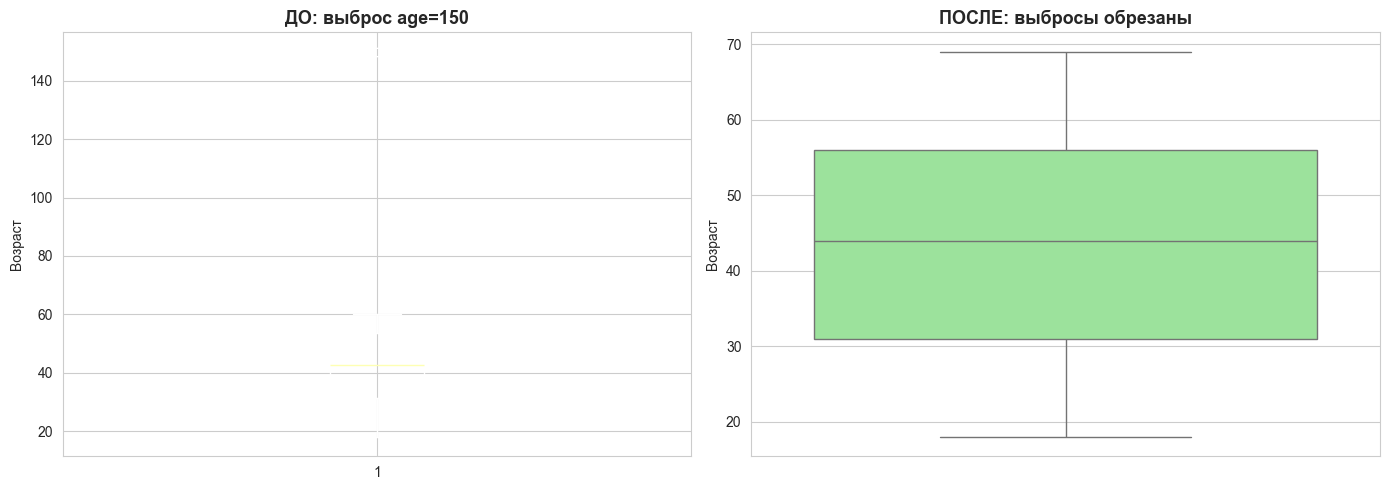

In [43]:
def cap_outliers(df, column, lower_percentile=1, upper_percentile=99):
    """Обрезка выбросов по процентилям"""
    lower = df[column].quantile(lower_percentile/100)
    upper = df[column].quantile(upper_percentile/100)
    df[column] = df[column].clip(lower, upper)
    return lower, upper

# Обрезаем выбросы
print('📊 Обрезка выбросов:\n')

for col in ['age', 'income', 'credit_score']:
    lower, upper = cap_outliers(data, col)
    print(f'{col}: [{lower:.0f}, {upper:.0f}]')

# Визуализация до/после
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# До (возьмём копию данных с выбросом)
# Примечание: в строке 61 мы установили age=150
axes[0].boxplot([18, 25, 30, 35, 40, 45, 50, 55, 60, 150]) # Иллюстративный пример
axes[0].set_title('ДО: выброс age=150', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Возраст')

# После
sns.boxplot(data=data, y='age', ax=axes[1], color='lightgreen')
axes[1].set_title('ПОСЛЕ: выбросы обрезаны', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Возраст')

plt.tight_layout()
plt.show()

## 🔧 Шаг 5: Обработка пропусков

### Стратегии импутации:
| Стратегия | Когда использовать |
|-----------|--------------------|
| **Среднее (mean)** | Нормальное распределение, нет выбросов |
| **Медиана (median)** | Есть выбросы, skewed распределение |
| **Мода (most_frequent)** | Категориальные данные |
| **KNN** | Есть коррелирующие признаки |
| **Константа** | Пропуск сам по себе информация |

In [44]:
# Разные стратегии импутации

# 1. Числовые: медиана (устойчива к выбросам)
imputer_median = SimpleImputer(strategy='median')
data[['income', 'credit_score']] = imputer_median.fit_transform(data[['income', 'credit_score']])

# 2. Категориальные: мода
imputer_mode = SimpleImputer(strategy='most_frequent')
data['city'] = imputer_mode.fit_transform(data[['city']]).ravel()

print('✅ Пропуски заполнены!')
print(f'Осталось пропусков: {data.isnull().sum().sum()}')

✅ Пропуски заполнены!
Осталось пропусков: 0


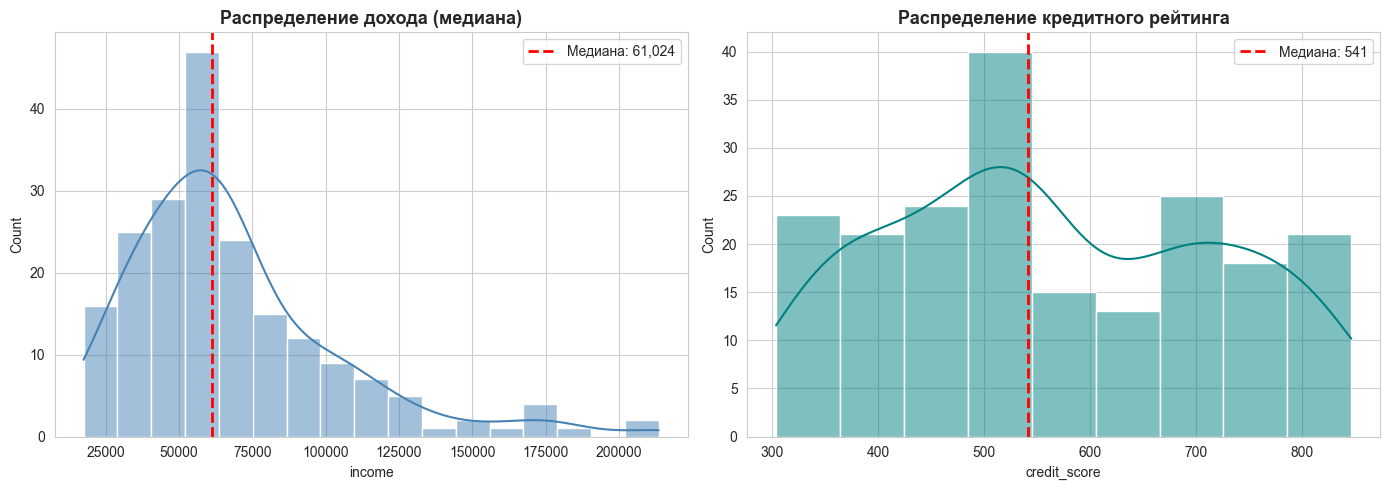

In [45]:
# Визуализация импутации
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Гистограмма income с отмеченной медианой
sns.histplot(data['income'], kde=True, ax=axes[0], color='steelblue')
median_income = data['income'].median()
axes[0].axvline(median_income, color='red', linestyle='--', linewidth=2, 
                label=f'Медиана: {median_income:,.0f}')
axes[0].set_title('Распределение дохода (медиана)', fontsize=13, fontweight='bold')
axes[0].legend()

# Гистограмма credit_score
sns.histplot(data['credit_score'], kde=True, ax=axes[1], color='teal')
median_cs = data['credit_score'].median()
axes[1].axvline(median_cs, color='red', linestyle='--', linewidth=2,
                label=f'Медиана: {median_cs:.0f}')
axes[1].set_title('Распределение кредитного рейтинга', fontsize=13, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

## 🎨 KNN Imputer: умная импутация

In [46]:
# KNN Imputer использует похожие записи для заполнения пропусков
data_knn = pd.DataFrame({
    'age': [25, 30, np.nan, 40, 45, 50, np.nan],
    'income': [50000, 70000, 90000, np.nan, 150000, 180000, 200000],
    'credit_score': [650, 700, 750, 800, np.nan, 720, 680]
})

print('📊 Данные с пропусками:')
display(data_knn)

# KNN Imputer
knn_imputer = KNNImputer(n_neighbors=3)
data_knn_imputed = pd.DataFrame(
    knn_imputer.fit_transform(data_knn),
    columns=data_knn.columns
)

print('\n✅ После KNN импутации:')
display(data_knn_imputed.round(1))


📊 Данные с пропусками:


,age,income,credit_score
0,25.0,50000.0,650.0
1,30.0,70000.0,700.0
2,NaN,90000.0,750.0
3,40.0,NaN,800.0
4,45.0,150000.0,NaN
5,50.0,180000.0,720.0
6,NaN,200000.0,680.0



✅ После KNN импутации:


,age,income,credit_score
0,25.0,50000.0,650.0
1,30.0,70000.0,700.0
2,31.7,90000.0,750.0
3,40.0,140000.0,800.0
4,45.0,150000.0,733.3
5,50.0,180000.0,720.0
6,45.0,200000.0,680.0


In [47]:
## 📊 Итоговый результат предобработки

print('📋 ИТОГОВЫЙ ОТЧЁТ:\n')
print(f'Записей: {len(data)}')
print(f'Пропусков: {data.isnull().sum().sum()}')
print(f'Дубликатов: {data.duplicated().sum()}')
print(f'\nУникальные значения категорий:')
for col in ['city', 'gender']:
    print(f'  {col}: {sorted(data[col].dropna().unique().astype(str))}')

print(f'\nСтатистика числовых признаков:')
display(data.describe().round(2))

📋 ИТОГОВЫЙ ОТЧЁТ:

Записей: 200
Пропусков: 0
Дубликатов: 0

Уникальные значения категорий:
  city: ['Казань', 'Москва', 'Спб']
  gender: ['F', 'M']

Статистика числовых признаков:


,age,income,credit_score,loan_amount
count,200.00,200.00,200.00,200.00
mean,43.64,68344.66,563.32,999276.30
std,14.99,36171.50,154.97,549772.47
min,18.00,17353.00,303.36,101062.00
25%,31.00,44451.50,443.00,531251.00
50%,44.00,61024.50,541.00,965913.50
75%,56.00,80067.50,695.00,1484765.50
max,69.00,213603.00,846.16,1985436.00


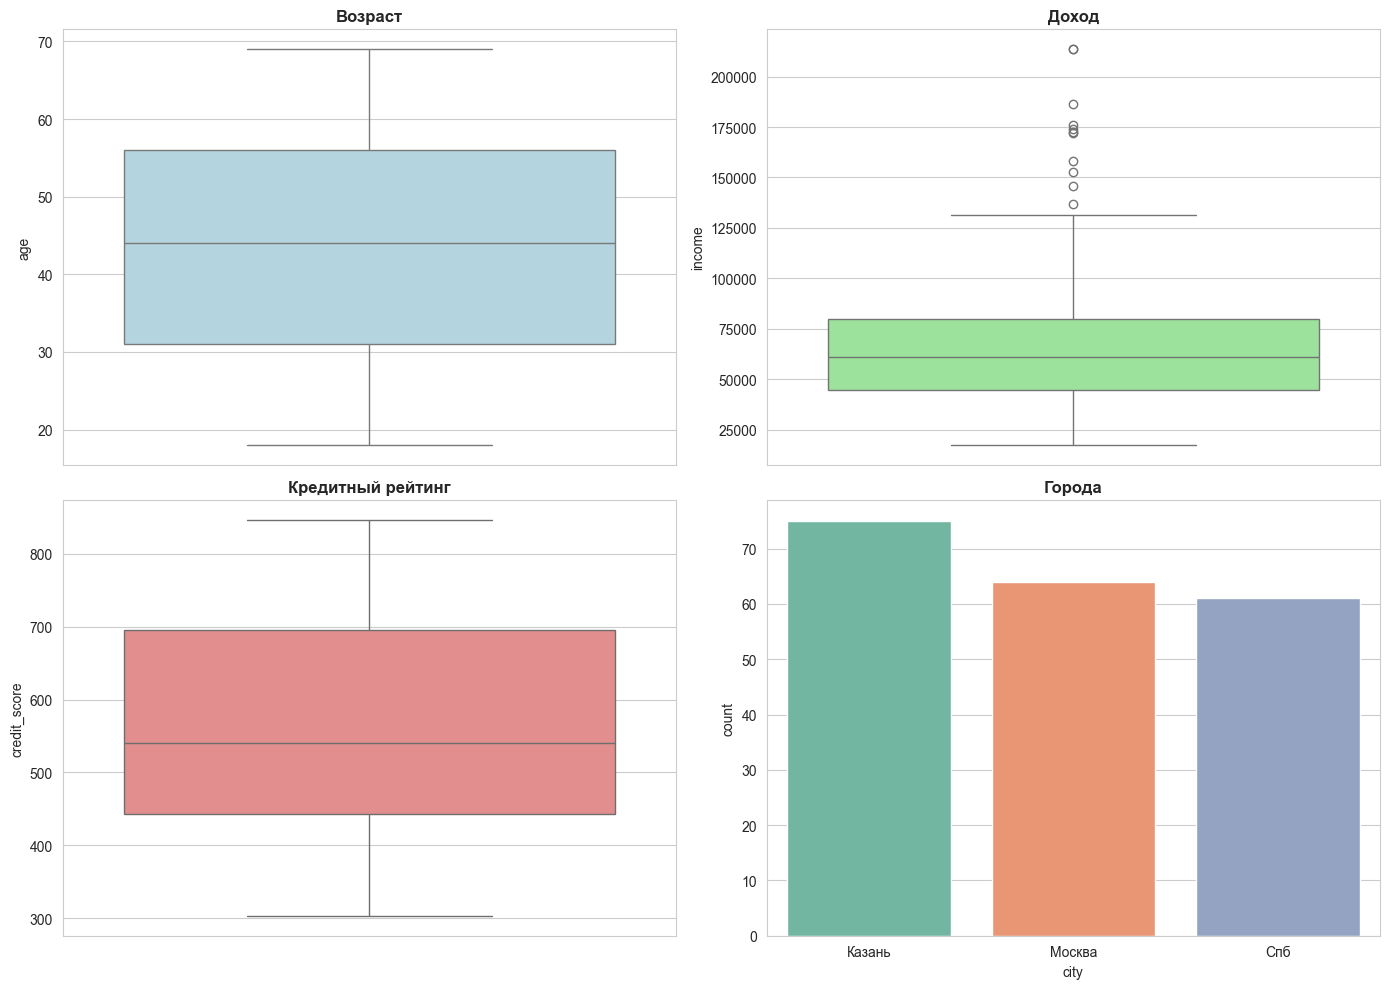


✅ Данные готовы к моделированию!


In [48]:
# Финальная визуализация чистых данных
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.boxplot(data=data, y='age', ax=axes[0, 0], color='lightblue')
axes[0, 0].set_title('Возраст', fontsize=12, fontweight='bold')

sns.boxplot(data=data, y='income', ax=axes[0, 1], color='lightgreen')
axes[0, 1].set_title('Доход', fontsize=12, fontweight='bold')

sns.boxplot(data=data, y='credit_score', ax=axes[1, 0], color='lightcoral')
axes[1, 0].set_title('Кредитный рейтинг', fontsize=12, fontweight='bold')

sns.countplot(data=data, x='city', ax=axes[1, 1], hue='city', palette='Set2', legend=False)
axes[1, 1].set_title('Города', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print('\n✅ Данные готовы к моделированию!')

## 💼 Применение в бизнесе

### Реальный кейс: Банк

**Проблема**: Модель кредитного скоринга работала плохо (accuracy 65%)

**Что нашли при аудите данных**:
- 25% пропусков в поле «доход супруга»
- Выбросы: возраст 120 лет, доход 1 млрд руб.
- Дубликаты заявок (одна заявка 3-4 раза)
- Разные форматы: «ИП», «ип», "ИП "

**После предобработки**:
- Accuracy вырос до 82%
- Одобрение плохих кредитов снизилось на 40%
- Экономия: 50 млн руб./год

---

## 📝 Чек-лист предобработки

- [ ] Удалить дубликаты
- [ ] Нормализовать категории (регистр, пробелы)
- [ ] Найти и обработать выбросы
- [ ] Заполнить пропуски (выбрать стратегию)
- [ ] Проверить типы данных
- [ ] Сохранить чистые данные

---

## 🎓 Практическое задание

1. Возьмите «грязный» датасет (например, с Kaggle)
2. Проведите полную предобработку по чек-листу
3. Сравните статистику до и после
4. Сохраните чистые данные в CSV

---

## ➡️ Что дальше?

В следующем уроке научимся **кодировать категориальные признаки** — превращать слова в числа, которые понимает модель.